In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpProblem, LpVariable, LpMaximize, LpMinimize, lpSum, value, LpStatus, PULP_CBC_CMD

# 1. Wczytanie danych i przygotowanie parametrów bazowych
df = pd.read_csv('Nuclear waste management.csv', index_col=0)
criteria = ['C1', 'C2', 'C3', 'C4']
variants = df.index.tolist()

# Nasze zdefiniowane preferencje
preferences = [
    (22, 3),   # Para 10
    (8, 7),    # Para 36
    (21, 10),  # Para 1
    (14, 25),  # Para 5
    (13, 18)   # Para 13
]

# Pobranie unikalnych, posortowanych wartości dla każdego kryterium
unique_values = {c: np.sort(df[c].unique()) for c in criteria}

print("Wszystko wczytane poprawnie")

Dane wczytane poprawnie. Gotowe do analizy!


--- ZADANIE 3: KLASYCZNA METODA UTA ---
Status: Optimal. Zoptymalizowana wartość epsilon = 0.2000

RANKING BAZOWY:
    Wariant  Uzytecznosc
1        14          0.9
2        13          0.9
3        26          0.8
4        24          0.8
5        23          0.8
6        21          0.8
7        20          0.8
8        15          0.8
9         1          0.8
10       27          0.8
... (wyświetlono TOP 10)



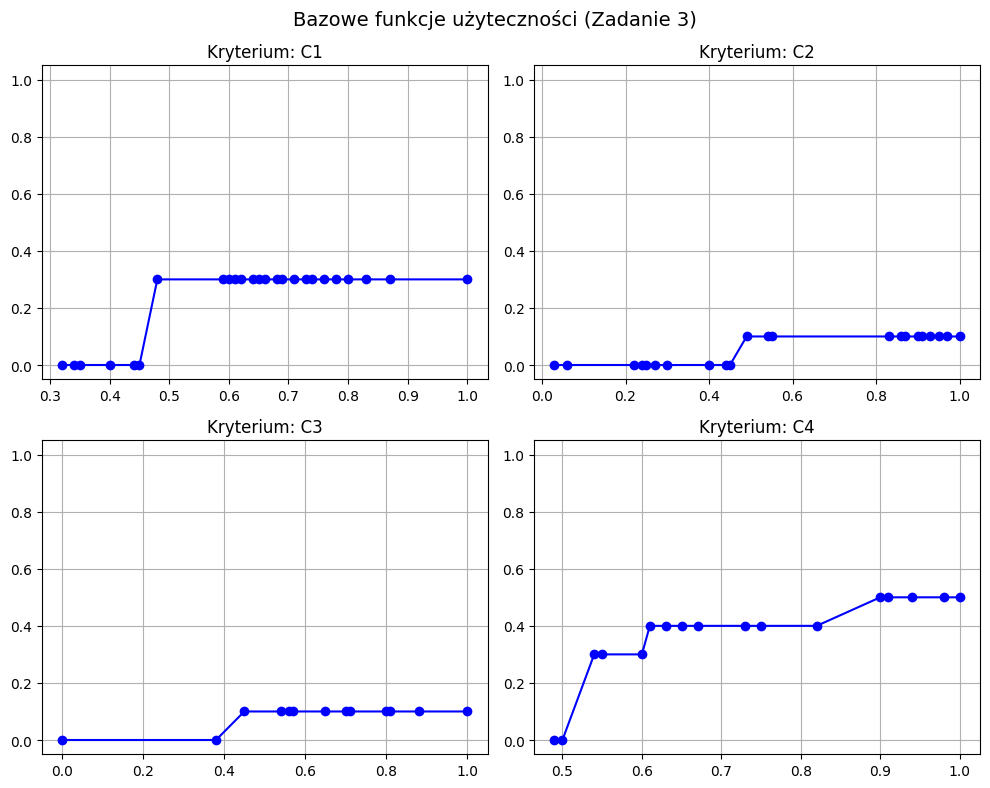

In [ ]:
print("--- ZADANIE 3: KLASYCZNA METODA UTA ---")

model_basic = LpProblem("UTA_Max_Epsilon", LpMaximize)
epsilon = LpVariable("epsilon", lowBound=0)

U_vars_basic = {c: {val: LpVariable(f"U_b_{c}_{val}".replace(".", "_"), lowBound=0) for val in unique_values[c]} for c in criteria}

# Ograniczenia
for c in criteria:
    vals = unique_values[c]
    model_basic += U_vars_basic[c][vals[0]] == 0
    model_basic += U_vars_basic[c][vals[-1]] >= 0.1
    for i in range(len(vals) - 1):
        model_basic += U_vars_basic[c][vals[i]] <= U_vars_basic[c][vals[i+1]]
        
model_basic += lpSum([U_vars_basic[c][unique_values[c][-1]] for c in criteria]) == 1.0

def get_global_utility_basic(var_id):
    return lpSum([U_vars_basic[c][df.loc[var_id, c]] for c in criteria])

for better, worse in preferences:
    model_basic += get_global_utility_basic(better) >= get_global_utility_basic(worse) + epsilon

model_basic += epsilon
model_basic.solve(PULP_CBC_CMD(msg=False))

if LpStatus[model_basic.status] == "Optimal":
    optimal_epsilon = value(epsilon)
    print(f"Status: Optimal. Zoptymalizowana wartość epsilon = {optimal_epsilon:.4f}\n")
    
    results_basic = []
    for variant in variants:
        global_u = sum([value(U_vars_basic[c][df.loc[variant, c]]) for c in criteria])
        results_basic.append({"Wariant": variant, "Uzytecznosc": global_u})
    
    results_df_basic = pd.DataFrame(results_basic).sort_values(by="Uzytecznosc", ascending=False).reset_index(drop=True)
    results_df_basic.index += 1
    
    print("RANKING BAZOWY:")
    print(results_df_basic.to_string())
    
    # Wykresy
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle("Bazowe funkcje użyteczności (Zadanie 3)", fontsize=14)
    for i, c in enumerate(criteria):
        ax = axes.flatten()[i]
        x_vals = unique_values[c]
        y_vals = [value(U_vars_basic[c][x]) for x in x_vals]
        ax.plot(x_vals, y_vals, marker='o', linestyle='-', color='b')
        ax.set_title(f"Kryterium: {c}")
        ax.grid(True)
        ax.set_ylim([-0.05, 1.05])
    plt.tight_layout()
    plt.show()
else:
    print("Model sprzeczny (Infeasible).")

In [6]:
print("--- ZADANIE 4: METODA UTA^GMS (Analiza odporności) ---")
print("Trwają obliczenia dla wszystkich par (to potrwa kilkanaście sekund)...")

epsilon_val = 0.01 

def solve_uta_gms(variant_A, variant_B, mode='max'):
    sense = LpMaximize if mode == 'max' else LpMinimize
    model = LpProblem("UTA_GMS", sense)
    U_vars = {c: {val: LpVariable(f"U_gms_{c}_{val}".replace(".", "_"), lowBound=0) for val in unique_values[c]} for c in criteria}
            
    for c in criteria:
        vals = unique_values[c]
        model += U_vars[c][vals[0]] == 0
        model += U_vars[c][vals[-1]] >= 0.1
        for i in range(len(vals) - 1):
            model += U_vars[c][vals[i]] <= U_vars[c][vals[i+1]]
    model += lpSum([U_vars[c][unique_values[c][-1]] for c in criteria]) == 1.0
    
    for better, worse in preferences:
        model += lpSum([U_vars[c][df.loc[better, c]] for c in criteria]) >= lpSum([U_vars[c][df.loc[worse, c]] for c in criteria]) + epsilon_val
        
    model += lpSum([U_vars[c][df.loc[variant_A, c]] for c in criteria]) - lpSum([U_vars[c][df.loc[variant_B, c]] for c in criteria])
    model.solve(PULP_CBC_CMD(msg=False))
    
    return value(model.objective) if LpStatus[model.status] == 'Optimal' else None

results_matrix = pd.DataFrame(index=variants, columns=variants, data="-")

for A in variants:
    for B in variants:
        if A == B:
            results_matrix.loc[A, B] = "N"
            continue
        min_diff = solve_uta_gms(A, B, mode='min')
        if min_diff is not None and min_diff >= -1e-5:
            results_matrix.loc[A, B] = "N"
        else:
            max_diff = solve_uta_gms(A, B, mode='max')
            if max_diff is not None and max_diff >= -1e-5:
                results_matrix.loc[A, B] = "P"

results_matrix.to_csv("UTA_GMS_Matrix.csv")
print("Obliczenia zakończone! Macierz zapisano jako 'UTA_GMS_Matrix.csv'.")
print("Fragment macierzy (10x10):")
print(results_matrix.to_string())

--- ZADANIE 4: METODA UTA^GMS (Analiza odporności) ---
Trwają obliczenia dla wszystkich par (to potrwa kilkanaście sekund)...
Obliczenia zakończone! Macierz zapisano jako 'UTA_GMS_Matrix.csv'.
Fragment macierzy (10x10):
   1  2  3  4  5  6  7  8  9  10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27
1   N  P  P  P  P  P  P  P  P  N  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P
2   P  N  P  P  P  P  P  P  P  P  N  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P
3   P  P  N  P  N  P  P  P  P  P  P  P  P  -  P  P  P  P  -  P  P  -  P  P  -  P  P
4   P  P  P  N  P  P  P  P  P  N  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P
5   P  P  P  P  N  P  P  P  P  P  P  P  P  -  P  P  P  P  -  P  P  -  P  P  -  P  P
6   P  P  P  P  P  N  P  P  P  P  P  P  P  -  P  P  P  P  P  P  P  P  P  P  -  P  P
7   P  P  P  P  P  P  N  -  P  P  P  P  P  -  P  P  P  P  P  P  P  P  P  P  P  P  P
8   P  P  P  P  P  P  N  N  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P
9   P  P  P  P  P  P  P 

--- ZADANIE 5: FUNKCJA REPREZENTATYWNA (Post-optymalizacja) ---
Używam zamrożonego epsilona: 0.2000. Uśredniam modele...
RANKING REPREZENTATYWNY (Wygładzony):
    Wariant  Uzytecznosc
1        14     0.931663
2        13     0.899949
3        21     0.852618
4        26     0.852618
5         1     0.831824
6         4     0.831780
7        20     0.791545
8        23     0.791527
9        27     0.788959
10       15     0.788958
... (wyświetlono TOP 10)



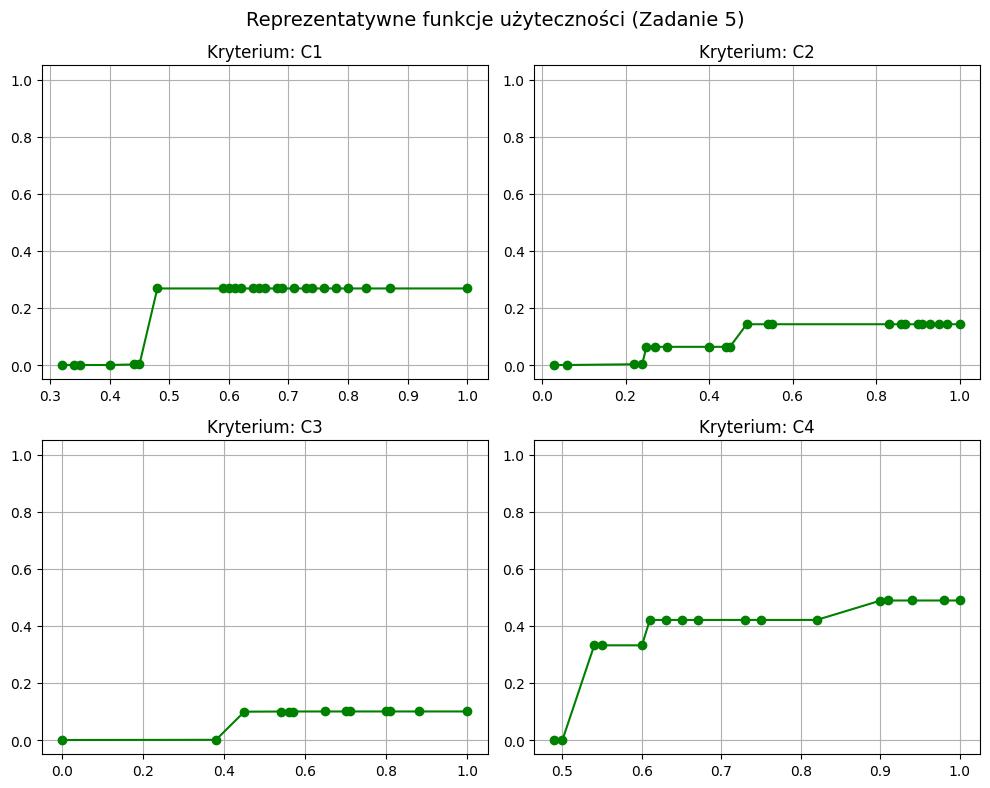

In [ ]:
print("--- ZADANIE 5: FUNKCJA REPREZENTATYWNA (Post-optymalizacja) ---")
print(f"Epsilon równy: {optimal_epsilon:.4f}")

variables_to_optimize = [(c, val) for c in criteria for val in unique_values[c]]
rep_U = {c: {val: 0.0 for val in unique_values[c]} for c in criteria}
num_optimizations = 0

for c_opt, val_opt in variables_to_optimize:
    for sense in [LpMaximize, LpMinimize]:
        model = LpProblem("UTA_Rep", sense)
        eps_var = LpVariable("epsilon", lowBound=0)
        U_vars = {c: {val: LpVariable(f"U_rep_{c}_{val}_{sense}_{c_opt}".replace(".", "_"), lowBound=0) for val in unique_values[c]} for c in criteria}
        
        for c in criteria:
            vals = unique_values[c]
            model += U_vars[c][vals[0]] == 0
            model += U_vars[c][vals[-1]] >= 0.1
            for i in range(len(vals) - 1):
                model += U_vars[c][vals[i]] <= U_vars[c][vals[i+1]]
        model += lpSum([U_vars[c][unique_values[c][-1]] for c in criteria]) == 1.0
        
        for better, worse in preferences:
            model += lpSum([U_vars[c][df.loc[better, c]] for c in criteria]) >= lpSum([U_vars[c][df.loc[worse, c]] for c in criteria]) + eps_var
            
        model += eps_var >= optimal_epsilon - 0.0001
        model += U_vars[c_opt][val_opt]
        model.solve(PULP_CBC_CMD(msg=False))
        
        if LpStatus[model.status] == 'Optimal':
            for c in criteria:
                for val in unique_values[c]:
                    rep_U[c][val] += value(U_vars[c][val])
            num_optimizations += 1

for c in criteria:
    for val in unique_values[c]:
        rep_U[c][val] /= num_optimizations

results_rep = [{"Wariant": v, "Uzytecznosc": sum([rep_U[c][df.loc[v, c]] for c in criteria])} for v in variants]
results_df_rep = pd.DataFrame(results_rep).sort_values(by="Uzytecznosc", ascending=False).reset_index(drop=True)
results_df_rep.index += 1

print("RANKING REPREZENTATYWNY (Wygładzony):")
print(results_df_rep.to_string())

# Wykresy
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Reprezentatywne funkcje użyteczności (Zadanie 5)", fontsize=14)
for i, c in enumerate(criteria):
    ax = axes.flatten()[i]
    x_vals = unique_values[c]
    y_vals = [rep_U[c][x] for x in x_vals]
    ax.plot(x_vals, y_vals, marker='o', linestyle='-', color='g')
    ax.set_title(f"Kryterium: {c}")
    ax.grid(True)
    ax.set_ylim([-0.05, 1.05])
plt.tight_layout()
plt.show()